# <font size=6><b>Lec04. [실습] YTN 뉴스 유사도

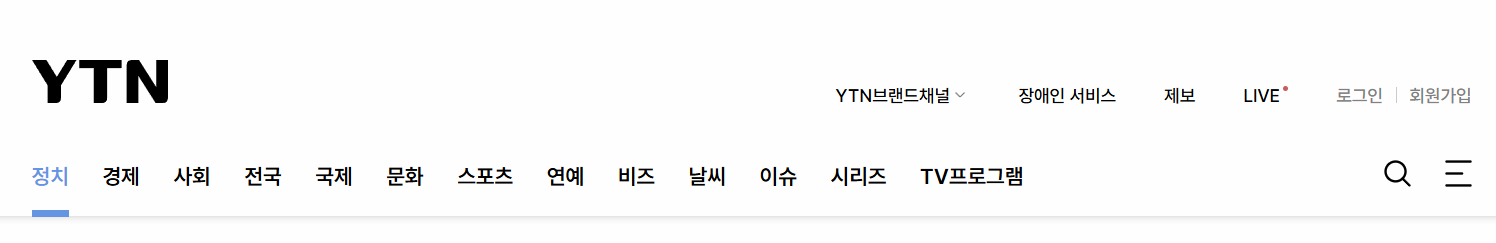
* https://www.ytn.co.kr/news/list.php?mcd=0101&page=

In [1]:
# pip install webdriver-manager

In [2]:
import requests

import pandas as pd
import random, time
from tqdm import tqdm

random.uniform(0.2, 1.2)

from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


# <b>크롤링 공통 함수

## DDL 

In [3]:
# ! pip install psycopg2-binary

In [4]:
import psycopg2
import duckdb

# 최초 1회 — psycopg2로 스키마 생성

PG_CONFIG = {
    "dbname":   "newsdb",
    "user":     "newsuser",
    "password": "news1234",
    "host":     "localhost",
    "port":     5432
}

# ============================================================
# 연결 함수
# ============================================================
def get_pg_conn():
    return psycopg2.connect(**PG_CONFIG)

def get_duck_conn():
    conn = duckdb.connect(':memory:')
    conn.execute("LOAD postgres")
    conn.execute(f"""
        ATTACH 'dbname={PG_CONFIG["dbname"]} user={PG_CONFIG["user"]}
        password={PG_CONFIG["password"]} host={PG_CONFIG["host"]}
        port={PG_CONFIG["port"]}'
        AS pg (TYPE postgres)
    """)
    return conn


def init_schema():
    pg = psycopg2.connect(**PG_CONFIG)
    cur = pg.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS craw_ytn_news (
            seq     SERIAL PRIMARY KEY,
            title   TEXT,
            content TEXT,
            cate    VARCHAR(50),
            rdate   VARCHAR(50),
            UNIQUE (title, rdate)   -- 중복 방지
        )
    """)
    pg.commit()
    cur.close()
    pg.close()
    print("스키마 초기화 완료")

init_schema()

스키마 초기화 완료


In [5]:
# 테이블 인식 확인
with get_pg_conn() as pg:
    with pg.cursor() as cur:
        cur.execute("""
            SELECT table_name 
            FROM information_schema.tables 
            WHERE table_schema = 'public'
        """)
        result = cur.fetchall()
        print(result)

[('craw_ytn_news',)]


In [6]:
# 샘플 데이터로 DuckDB → PostgreSQL 전송 확인
with get_pg_conn() as pg:
    with pg.cursor() as cur:
        cur.execute("""
            INSERT INTO craw_ytn_news (title, content, cate, rdate)
            VALUES ('테스트 제목', '테스트 본문', '정치', '2025-01-01')
            ON CONFLICT (title, rdate) DO NOTHING
        """)
        pg.commit()
        
        cur.execute("SELECT * FROM craw_ytn_news")
        result = cur.fetchall()
        print(result)

        # 수정 — 테스트 후 정리
        cur.execute("DELETE FROM craw_ytn_news WHERE title = '테스트 제목'")
        pg.commit()


[(5, "광화문 '보라빛' 물들인 BTS...전 세계가 '환호'", "■ 진행 : 정지웅 앵커\r■ 출연 : 임희윤 대중음악평론가* 아래 텍스트는 실제 방송 내용과 차이가 있을 수 있으니 보다 정확한 내용은 방송으로 확인하시기 바랍니다. 인용 시 [YTN 뉴스와이드] 명시해주시기 바랍니다. [앵커]\r3년 9개월 만의 '군백기'를 끝내고'완전체'로 돌아온 방탄소년단,어젯밤 광화문을 넘어 전 세계를보라빛으로 물들였습니다. 임희윤 대중음악평론가 모시고 어젯밤 광화문 공연과BTS 컴백 얘기 나눠보겠습니다. 평론가님, 직접 보셨습니까?[임희윤]\r광화문 가서 보고 왔습니다.[앵커]\r가장 인상깊었던 부분은 뭐였습니까?[임희윤]\r일단 광화문 광장 일대가 굉장히 독특한 편성으로 해서 관객들로 가득차고 응원봉 같은 것들이 불빛으로 가득차서 그런 광경이 월드컵 응원이나 이런 때랑은 분위기가 많이 다르더라고요. 그래서 굉장히 특이한 분위기였습니다.[앵커]\r반대로 가셔서 직접 보셨기 때문에 아쉬웠던 부분이 있다면 어떤 게 있었을까요?[임희윤]\r아무래도 장소가 장소이니만큼 저희한테 특별한 문화적인 중심이잖아요. 그래서 앞서 주최 측에서 예고했던 것도 그렇고 경복궁, 광화문 그리고 광장 일대의 아름다움 같은 것들이 보여질 거라고 기대를 많이 했는데 밤이기도 했고 여러 가지 조명 같은 게 무대에 많이 집중됐던 것 같아요. 무대 자체는 굉장히 훌륭하고 멋졌는데 경복궁, 광화문 심지어 그 공간 안에는 이순신 동상이라든지 세종대왕상 같은 것들이 있지 않습니까? 이런 것들에 대한 조명이나 아름다움을 비추는 부분이 아쉬웠고 그것보다는 퍼포먼스 자체 그리고 전체적으로 부감샷으로 광화문 세종대로 이쪽을 전체적으로 잡는 샷, 이런 것들이 많았기 때문에 우리들의 아름다움을 제대로 보여준다기보다는 방탄소년단을 멋지게 보여준 그런 것에 집중했던 것이 약간의 아쉬움들이 남았습니다.[앵커]\r말씀해 주신 것의 연장선일 수도 있는데 단순한 컴백쇼가 아니라 국가급의 행사였잖아요. 거기에 걸맞는 준비가 

## DB연동

## YTN 크롤링 

In [7]:

# ============================================================
# 1. 크롤링 — 데이터 수집만 담당, 리스트 반환
# ============================================================
def crawl(urlprm, cate, range_cnt=3):
    service = Service(ChromeDriverManager().install())
    options = Options()
    options.add_argument("--start-maximized")
    driver = webdriver.Chrome(service=service, options=options)
    driver.get(urlprm)

    news_list = []

    for i in tqdm(range(range_cnt)):
        print(f"{i+1}번 크롤링 시작")
        try:
            time.sleep(round(random.uniform(0.2, 1.2), 2))
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            div_list = soup.select(
                "#container > div > div.content > div > div.news_list_wrap > div"
            )
            print("현재 게시물 수:", len(div_list))

            for li_tag in div_list:
                try:
                    title = li_tag.select_one('div.text_area > div.title > a').text
                    href  = li_tag.select_one('div.text_area > div.title > a').get("href")
                    rdate = li_tag.select_one('div.text_area > div.info > div.date').text

                    response_sub = requests.get(href)
                    if response_sub.status_code == 200:
                        time.sleep(round(random.uniform(0.2, 1.2), 2))
                        html_soup = BeautifulSoup(response_sub.text, 'html.parser')
                        content = html_soup.select_one("#CmAdContent > span").text
                        temp = "".join(cc for cc in content.rsplit("\n") if len(cc) > 2)

                        news_list.append({
                            "title":   title,
                            "content": temp[:4000],
                            "cate":    cate,
                            "rdate":   rdate
                        })
                except Exception as e:
                    print(f"에러: {e}")
                    continue

            btn = WebDriverWait(driver, 2).until(
                EC.element_to_be_clickable((By.CSS_SELECTOR, "a.btn_white_arr_down"))
            )
            driver.execute_script("arguments[0].click();", btn)

        except Exception:
            print("에러발생")
            continue

    driver.quit()
    return news_list  # 딕셔너리 리스트 반환


# ============================================================
# 2. 전처리 — DuckDB 담당, 추후 로직 추가 예정
# ============================================================
def preprocess(news_list):
    conn = duckdb.connect(':memory:')

    # 리스트 → DuckDB 테이블
    conn.execute("""
        CREATE TABLE raw_news (
            title   TEXT,
            content TEXT,
            cate    VARCHAR(50),
            rdate   VARCHAR(50)
        )
    """)
    conn.executemany(
        "INSERT INTO raw_news VALUES (?, ?, ?, ?)",
        [(r["title"], r["content"], r["cate"], r["rdate"]) for r in news_list]
    )

    # 추후 전처리 로직 추가 예정
    # ex) 중복 제거, 텍스트 정제, 컬럼 추가 등
    result = conn.execute("SELECT DISTINCT * FROM raw_news").fetchall()
    conn.close()
    return result  # 튜플 리스트 반환


# ============================================================
# 3. 저장 —  psycopg2 전담 (SERIAL 호환성 문제 해결)
# ============================================================
def save_to_pg(data):
    with get_pg_conn() as pg:
        with pg.cursor() as cur:
            cur.executemany("""
                INSERT INTO craw_ytn_news (title, content, cate, rdate)
                VALUES (%s, %s, %s, %s)
                ON CONFLICT (title, rdate) DO NOTHING
            """, data)
            pg.commit()
    
            cur.execute("SELECT COUNT(*) FROM craw_ytn_news")
            count = cur.fetchone()[0]
    
    print(f"저장 완료 — 누적 {count}건")

# ============================================================
# 4. 실행부
# ============================================================
def run(urlprm, cate, range_cnt=3):
    print("1. 크롤링 시작")
    raw = crawl(urlprm, cate, range_cnt)
    print(f"   수집 완료: {len(raw)}건")

    print("2. 전처리 시작")
    processed = preprocess(raw)
    print(f"   전처리 완료: {len(processed)}건")

    print("3. PostgreSQL 저장 시작")
    save_to_pg(processed)

# <b>분야별 뉴스 크롤링

* 정치  == 1, 문화 == 2

In [8]:
res = run("https://www.ytn.co.kr/news/list.php?mcd=0106", cate=2,range_cnt=5)  #range_cnt=3

1. 크롤링 시작


  0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

1번 크롤링 시작
현재 게시물 수: 10


 20%|██████████████████████████████▍                                                                                                                         | 1/5 [00:08<00:33,  8.33s/it]

2번 크롤링 시작
현재 게시물 수: 20


...

4번 크롤링 시작
현재 게시물 수: 40


 80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                              | 4/5 [01:21<00:23, 23.35s/it]

5번 크롤링 시작
현재 게시물 수: 50


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:04<00:00, 24.86s/it]


   수집 완료: 150건
2. 전처리 시작
   전처리 완료: 50건
3. PostgreSQL 저장 시작
저장 완료 — 누적 50건


In [9]:
res = run("https://www.ytn.co.kr/news/list.php?mcd=0101", cate=1,range_cnt=5 )  #range_cnt=3

1. 크롤링 시작


  0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

1번 크롤링 시작
현재 게시물 수: 10


 20%|██████████████████████████████▍                                                                                                                         | 1/5 [00:07<00:31,  7.87s/it]

2번 크롤링 시작
현재 게시물 수: 20


...

4번 크롤링 시작
현재 게시물 수: 40


 80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                              | 4/5 [01:18<00:22, 22.51s/it]

5번 크롤링 시작
현재 게시물 수: 50


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:01<00:00, 24.27s/it]


   수집 완료: 150건
2. 전처리 시작
   전처리 완료: 50건
3. PostgreSQL 저장 시작
저장 완료 — 누적 100건


In [13]:
processed

NameError: name 'processed' is not defined